In [15]:
import importlib
import processing_fun
importlib.reload(processing_fun)
from utils import OperonArgs
import matplotlib.pyplot as plt
from os.path import join as pjoin
import numpy as np
import sr_fun
importlib.reload(sr_fun)
import pandas as pd
import re
import scipy.optimize

# IOB Fits


Reading from configuration file: conf/iob_36.ini

Reading from configuration file: conf/selection_1.ini

Target: A

All model lengths:
[ 5  7  9 11 12 13 14 17 18 21 24 26 31 32 33]

Equation requested:
((-0.037862) + (1.026372 * (((((sqrt((3.192068 * X5)) ^ (((19.200712 * X2) - ((-21.921675) * X1)) - ((191.181320 * X5) - 89.716148))) + ((4.825106 * X1) + (12.604479 * X2))) - ((-0.549189) + ((-11.069893) * X3))) - (0.312394 * X5)) * (((log((3.824345 * X5)) + (1.615912 * X1)) * log((0.749569 * X5))) ^ 2))))

Equation with pars
1.026372*(1.615912*IOB1 + log(3.824345*lam))**2*(4.825106*IOB1 + 12.604479*IOB2 + 11.069893*IOB3 - 0.312394*lam + (1.7866359450095*sqrt(lam))**(21.921675*IOB1 + 19.200712*IOB2 - 191.18132*lam + 89.716148) + 0.549189)*log(0.749569*lam)**2 - 0.037862

Converted equation:
c0*(c1*IOB1 + log(c2*lam))**2*(c3*IOB1 + c4*IOB2 + c5*IOB3 - c6*lam + (c7*sqrt(lam))**(c8*IOB1 + c9*IOB2 - c10*lam + c11) + c12)*log(c13*lam)**2 - c14

Number of parameters: 15
Values: [1.026372, 1

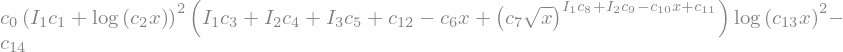


Latex version:
c_{0} \left(I_{1} c_{1} + \log{\left(c_{2} x \right)}\right)^{2} \left(I_{1} c_{3} + I_{2} c_{4} + I_{3} c_{5} + c_{12} - c_{6} x + \left(c_{7} \sqrt{x}\right)^{I_{1} c_{8} + I_{2} c_{9} - c_{10} x + c_{11}}\right) \log{\left(c_{13} x \right)}^{2} - c_{14}

Value at x=1:


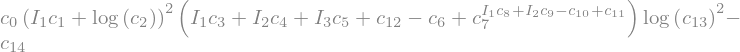


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Reparameterising expression:
Original number of parameters: 18
Temporary global prefix: b, temporary local prefix: d
Old local parameters: ['IOB1', 'IOB2', 'IOB3']
Final number of parameters: 10
Of which global: 7 and local: 3
Final values: [-0.0378620000000000, 1.026372, 0.749569, 3.824345, 1.7866359450095, -191.181320000000, -0.312394000000000]
Local replacements: {B0: IOB1*c1, B1: IOB1*c3 + IOB2*c4 + IOB3*c5 + c12, B2: IOB1*c8 + IOB2*c9 + c11}


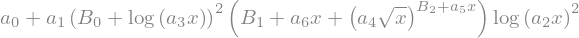


Latex version:
a_{0} + a_{1} \left(B_{0} + \log{\left(a_{3} x \right)}\right)^{2} \left(B_{1} + a_{6} x + \left(a_{4} \sqrt{x}\right)^{B_{2} + a_{5} x}\right) \log{\left(a_{2} x \right)}^{2}

Value at x=1:


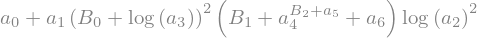

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Generating code...
Saved code to sr_fun.py

Reading from configuration file: conf/iob_36.ini

Reading from configuration file: conf/selection_1.ini

Target: A

RMSE train: 3.894e-01
		1 sigma: -0.33444897486189623 0.14287934602193977
		RMSE: 0.15499664855792905
		RMAE: 0.08772191780895286
		1 sigma: -0.15586608183039374 0.11391230948620497
Median absolute DF/F 0.022384343030922293
RMSE DF/F 0.07918507184545227

RMSE val: 3.584e-01
		1 sigma: -0.32365788422707964 0.14115864302527042
		RMSE: 0.15745861442018794
		RMAE: 0.08981424575142886
		1 sigma: -0.15664727521775013 0.11257752223759994
Median absolute DF/F 0.02173077474439078
RMSE DF/F 0.07100387138913021

Reading from configuration file: conf/iob_36.ini

Reading from configuration file: conf/selection_1.ini

Target: A


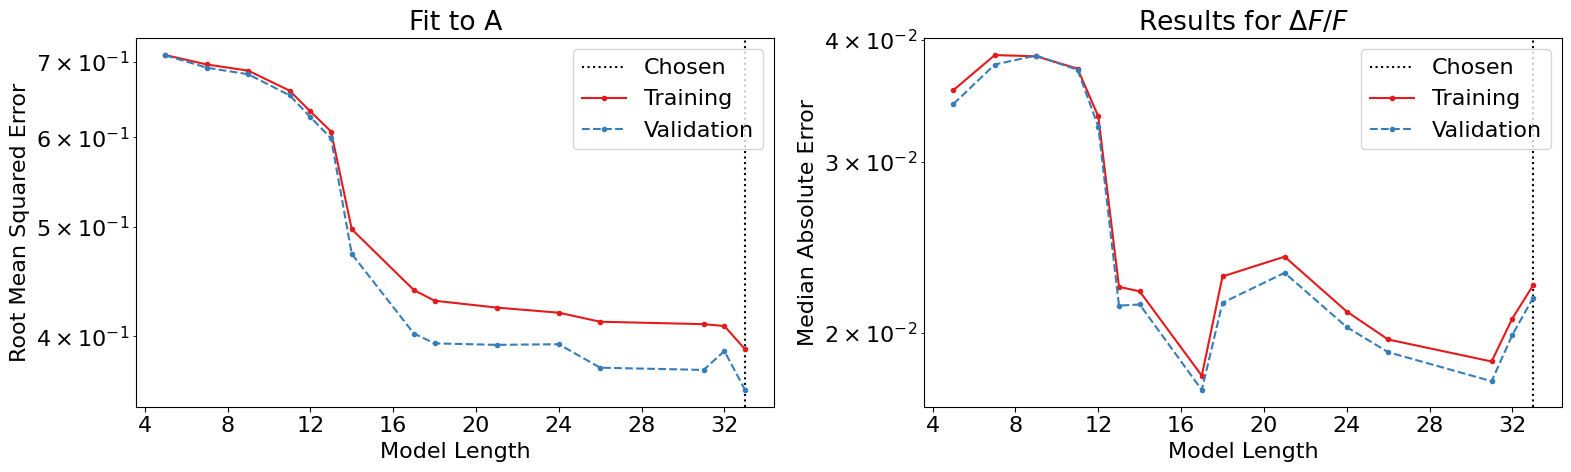

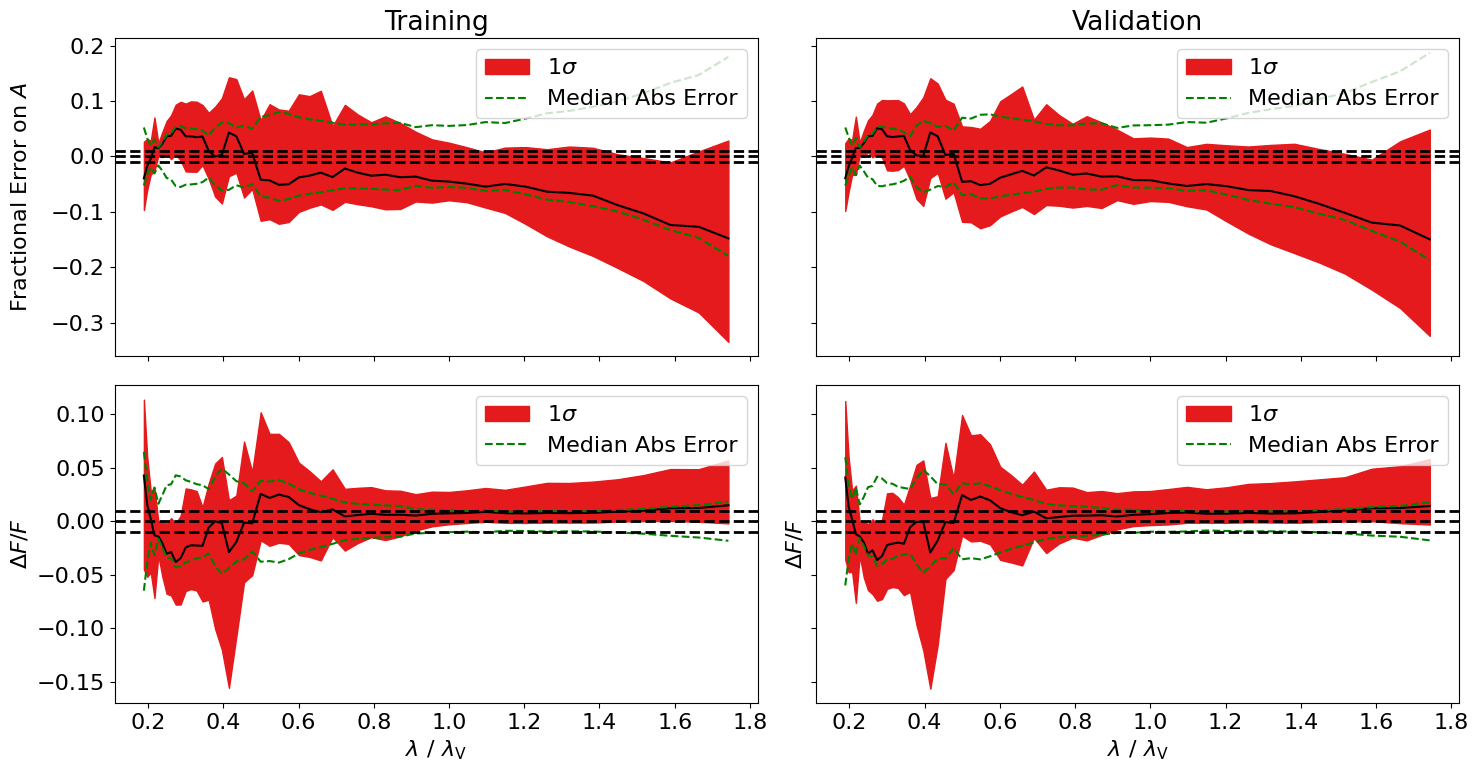

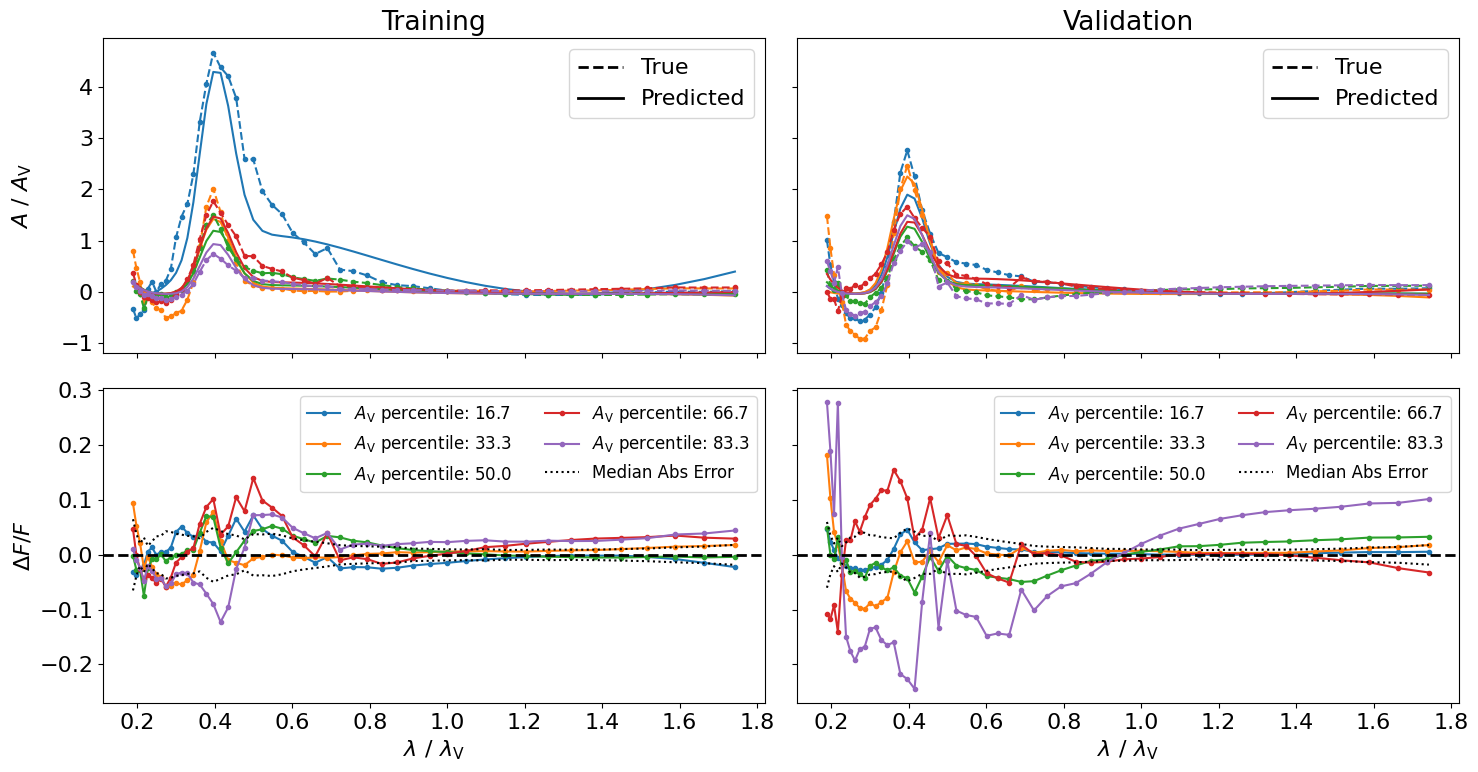

In [16]:
ini_file = 'conf/iob_0.ini'; ilen = None
ini_file = 'conf/iob_1.ini'; ilen = None
ini_file = 'conf/iob_2.ini'; ilen = None
ini_file = 'conf/iob_3.ini'; ilen = None
ini_file = 'conf/iob_4.ini'; ilen = None
# ini_file = 'conf/iob_5.ini'; ilen = None
# ini_file = 'conf/iob_6.ini'; ilen = None
# ini_file = 'conf/iob_7.ini'; ilen = 40
# ini_file = 'conf/iob_8.ini'; ilen = 29
ini_file = 'conf/iob_9.ini'; ilen = 32; ilen = 13 # No bump

# ini_file = 'conf/iob_10.ini'; ilen = None; ilen = 28 # No bump - remove exp from basis
# ilen = 15

# ini_file = 'conf/iob_11.ini'; ilen = None # Full curve, 24hr
# ini_file = 'conf/iob_12.ini'; ilen = 48 # Full curve, 24hr, add aq to basis
# ini_file = 'conf/iob_13.ini'; ilen = None # Full curve, 48hr
# ini_file = 'conf/iob_14.ini'; ilen = None # Full curve, 48hr, add aq to basis

# ini_file = 'conf/iob_15.ini'; ilen = None; ilen=56  # Full curve, 24hr, linear space
# NOTE: ilen=56 looks like denominator could have a zero, but the minimum of this is
# ~0.0294 at x=0.38 for any x, so it's fine.
# ilen=56 is my favourite up to run 16. Need to check overall minimum etc.
# Problem as x -> inf? Looks like it goes to 1, but wanted 0?
# ilen = 41

# ini_file = 'conf/iob_16.ini'; ilen = None # Full curve, 24hr, add aq to basis, linear space

ini_file = 'conf/iob_17.ini'; ilen = 64 # Full curve, 48hr, linear space
# ini_file = 'conf/iob_18.ini'; ilen = 40 # Full curve, 48hr, linear space

# ini_file = 'conf/iob_19.ini'; ilen = 74
# ini_file = 'conf/iob_20.ini'; ilen = 45
# ini_file = 'conf/iob_21.ini'; ilen = 63

# ini_file = 'conf/iob_22.ini'; ilen = None  # No bump but MSE error

# No bump and short max model length
# ini_file = 'conf/iob_23.ini'; ilen = None
# ini_file = 'conf/iob_24.ini'; ilen = 13
# ini_file = 'conf/iob_25.ini'; ilen = 13
# ini_file = 'conf/iob_26.ini'; ilen = 13
# # ini_file = 'conf/iob_27.ini'; ilen = 14
# ini_file = 'conf/iob_28.ini'; ilen = 19
# ini_file = 'conf/iob_29.ini'; ilen = 15
# # ini_file = 'conf/iob_30.ini'; ilen = 14
# # ilen = 15
ini_file = 'conf/iob_31.ini'; ilen = 15
# run 32 failed (node error)
ini_file = 'conf/iob_35.ini'; ilen = 13  # THIS IS WHAT IS CHOSEN FOR THE OUTER FUNCTION

# Back to full curve fits with MSE
# ini_file = 'conf/iob_33.ini'; ilen = 65;
# ini_file = 'conf/iob_34.ini'; ilen = 65

# Full curve where we subtract outer first
ini_file = 'conf/iob_36.ini'; ilen = None

args = OperonArgs(ini_file, verbose=False)
processing_fun.plot_pareto(ini_file, ilen=ilen, prefix='c')
processing_fun.prediction_plots(ini_file, ilen=ilen, plot_frac_error=True);
processing_fun.plot_example(ini_file, ilen=ilen, nexamples=5, plot_av_diff=False, plot_dF_F=True, yscale='linear', subtract_outer=args.subtract_outer);
# processing_fun.compare_to_literature(ini_file, ilen=ilen, which_gals='all', use_optimised=False);

Test output code


Reading from configuration file: conf/iob_31.ini

Reading from configuration file: conf/selection_1.ini

Reading from configuration file: conf/iob_31.ini

Reading from configuration file: conf/selection_1.ini
Galaxy ID: 720251.0, LOS: 16.0
IOB values: [-0.028115  0.002932 -0.007467 -0.001387  0.002089 -0.001554  0.000629
 -0.001419]
Computed B parameters: -0.027973047365000003
(1473, 8)
1070
-0.07853446728300001 0.243605792742 0.004746363423809912


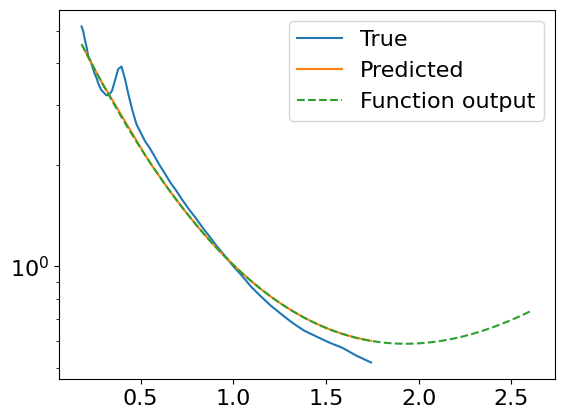

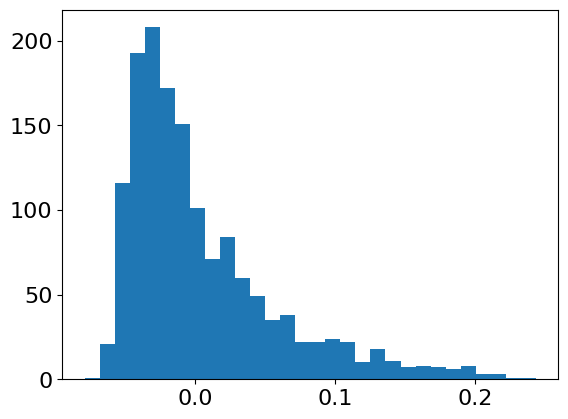

In [45]:
name = 'train'
# ini_file = 'conf/iob_6.ini'; ilen = 32
# ini_file = 'conf/iob_29.ini'; ilen = 15
# ini_file = 'conf/iob_30.ini'; ilen = 14

args = OperonArgs(ini_file)

fname = args.selection.train_file if name == 'train' else args.selection.val_file
data_train = pd.read_csv(fname)
iob_cols = sorted([col for col in data_train.columns if re.match(r'IOB\d+', col)])
lam_cols = [col for col in data_train.columns if re.match(r'A_\d+', col)]
ytrue = data_train[lam_cols].values
A_v_col = f'A_{int(args.lambda_V*1e4)}A'
A_v = data_train[A_v_col].values
lam = np.array([int(re.search(r'_(\d+)', col).group(1)) / 1e4 for col in lam_cols])
x = lam / args.lambda_V

# Get AV
attenuation_cols = [col for col in data_train.columns if re.match(r'A_\d+A', col)]
lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
v_index = processing_fun.find_nearest(lam_arr,0.551)

# Get operon data for prediction
args = OperonArgs(ini_file)
run_name = f'{args.in_param}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = f'{out_dir}/{run_name}_fun.csv'
df = pd.read_csv(fname, delimiter=';')
if ilen is None:
    eq_idx = -1
else:
    eq_idx = list(df['Length']).index(ilen)
length = list(df['Length'])[eq_idx]
fname = f'{out_dir}/{run_name}_{name}_{length}.csv'
data = np.loadtxt(fname)
ypred = data[:,args.npar+2]
dirname = pjoin(args.out_data_dir, f'{args.in_param}_data_{args.version_num}')
fname = pjoin(dirname, f'{args.in_param}_train_data.txt')
with open(fname, 'r') as f:
    header = f.readline().split()
x_sub = np.unique(np.loadtxt(fname, skiprows=1)[:,header.index('lam')])
ypred = ypred.reshape(-1, len(x_sub))

importlib.reload(sr_fun)
xplot = np.linspace(np.min(x), 1.5*np.max(x), 100)

for i in [10]:
    print(f'Galaxy ID: {data_train["galaxy_id"].values[i]}, LOS: {data_train["los"].values[i]}')
    IOB = data_train[iob_cols].values[i]
    print(f"IOB values: {IOB}")
    B = sr_fun.compute_initial_B(IOB)
    print(f'Computed B parameters: {B}')
    if np.isscalar(B):
        B = (B,)
    new_pred = sr_fun.compute_Av(xplot, *B)
    # new_pred = compute_Av(xplot, *B)
    if args.fit_log:
        new_pred = 10. ** new_pred

    plt.plot(x, ytrue[i] / A_v[i], label='True')
    plt.plot(x_sub, ypred[i], label='Predicted')
    plt.plot(xplot, new_pred, label='Function output', ls='--')
    plt.legend()

#     print(np.sqrt(np.mean((new_pred - ypred[i])**2)))
#     print(np.sqrt(np.mean((ypred[i] - ytrue[i])**2)))

plt.yscale('log')

# A_err_op = [None] * getattr(args, f'n{name}')
# df_F_op = [None] * getattr(args, f'n{name}')
# for j in range(getattr(args, f'n{name}')):
#     A_err_op[j] = ypred[j*len(lam):(j+1)*len(lam)] - ytrue[j*len(lam):(j+1)*len(lam)]
#     df_F_op[j] = data[j*len(lam):(j+1)*len(lam),args.npar+3]

# # Get AV
# attenuation_cols = [col for col in all_data.columns if re.match(r'A_\d+A', col)]
# lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
# v_index = processing_fun.find_nearest(lam_arr,0.551)
# Av_name = attenuation_cols[v_index]
# Av = data_train[Av_name].values

IOB = data_train[iob_cols].values
print(IOB.shape)
B = sr_fun.compute_initial_B(IOB.T)
print(np.argmax(B))
plt.figure()
plt.hist(B, bins=30)
print(np.min(B), np.max(B), np.mean(B))



Fitted tanh parameters: A=2.262279396227433, B=0.7592281966296044, C=1.2482650712040162
Galaxy ID: 720251.0, LOS: 16.0
IOB values: [-0.028115  0.002932 -0.007467 -0.001387  0.002089 -0.001554  0.000629
 -0.001419]
Computed B parameters: -0.027973047365000003


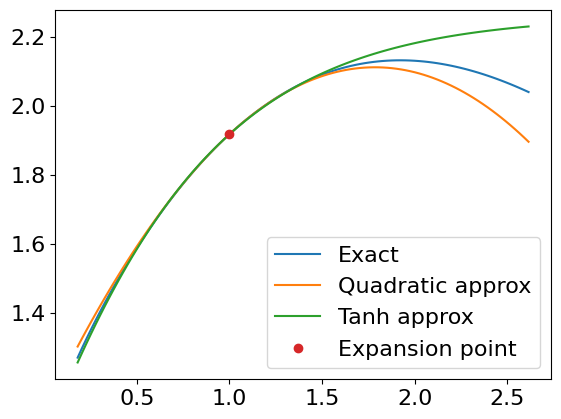

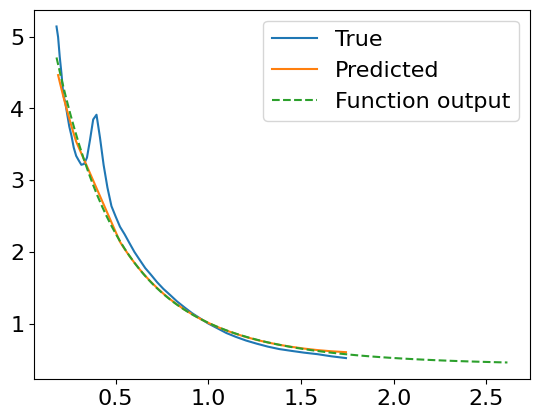

In [61]:
# i = 10
# xplot = np.linspace(np.min(x), 1.5*np.max(x), 100)
# IOB = data_train[iob_cols].values[i]
# print(f"IOB values: {IOB}")
# B = sr_fun.compute_initial_B(IOB)
# a = [-0.0123170000000000, -0.481067000000000, 1.015321, 4.279083, -2.19217600000000, 0.198605]
# # A_over_Av = a[0] + a[2]*(B0 - (a[3]*xplot)**B1)*(a[4] + (a[5]*xplot)**(a[1]*xplot))
# plt.axhline(a[4])
# plt.plot(xplot, (a[5]*xplot)**(a[1]*xplot))

a = [-0.00720300000000000, -0.394022000000000, 0.91748, -1.92882800000000, -2.47409200000000, 6.9e-05, 0.191431]

# Quadratic approximation
a_val = a[6]
b = a[1]

a0 = a_val ** b
a1 = b * (np.log(a_val) + 1) * a_val ** b
a2 = b * a_val ** b * (1 + b * (np.log(a_val) + 1)**2)
h  = xplot - 1

def approx_fun(x, A, B, C):
    return A * np.tanh(B * (x - 1) + C)

# Get approximation as a tanh function
xfit = np.linspace(0.5, 1.5, 50)
y = (a_val*xfit)**(b*xfit)
res = scipy.optimize.curve_fit(approx_fun, xfit, y, p0=[a0, 2., 0])
A_fit, B_fit, C_fit = res[0]
print(f'Fitted tanh parameters: A={A_fit}, B={B_fit}, C={C_fit}')
y_tanh = approx_fun(xplot, A_fit, B_fit, C_fit)

plt.plot(xplot, (a_val*xplot)**(b*xplot), label='Exact')
plt.plot(xplot, a0 + a1*h + 0.5*a2*h**2, label='Quadratic approx')
plt.plot(xplot, y_tanh, label='Tanh approx')
plt.plot([1.], [a0], 'o', label='Expansion point')
plt.legend()

def compute_Av(x, B0):
    a = [-0.00720300000000000, -0.394022000000000, 0.91748, -1.92882800000000, -2.47409200000000, 6.9e-05, 0.191431]
    # A_over_Av = a[0] + a[2]*(a[3] + (a[6]*x)**(a[1]*x))*(a[4] + (a[5]*x)**B0)
    A_over_Av = a[0] + a[2]*(a[3] + approx_fun(x, A_fit, B_fit, C_fit))*(a[4] + (a[5]*x)**B0)
    return A_over_Av

plt.figure()
for i in [10]:
    print(f'Galaxy ID: {data_train["galaxy_id"].values[i]}, LOS: {data_train["los"].values[i]}')
    IOB = data_train[iob_cols].values[i]
    print(f"IOB values: {IOB}")
    B = sr_fun.compute_initial_B(IOB)
    print(f'Computed B parameters: {B}')
    if np.isscalar(B):
        B = (B,)
    new_pred = compute_Av(xplot, *B)
    if args.fit_log:
        new_pred = 10. ** new_pred

    plt.plot(x, ytrue[i] / A_v[i], label='True')
    plt.plot(x_sub, ypred[i], label='Predicted')
    plt.plot(xplot, new_pred, label='Function output', ls='--')
    plt.legend()


# Optimise outer term

Now we have a functional form for the outer term, we manipulate the function and try to re-optimise its parameters


Reading from configuration file: conf/iob_35.ini

Reading from configuration file: conf/selection_1.ini
(54501, 8) (54501,)

Initial b parameters: [0.9753444117120513, 0.944124]
Training loss with initial b: 0.09391890558372663
Validation loss with initial b: 0.08960616006489754

True, Optimization terminated successfully.

Optimised b parameters: [1.00793398 0.97752676]
Training loss with optimised b: 0.07165507154363666
Validation loss with optimised b: 0.06751158381571837


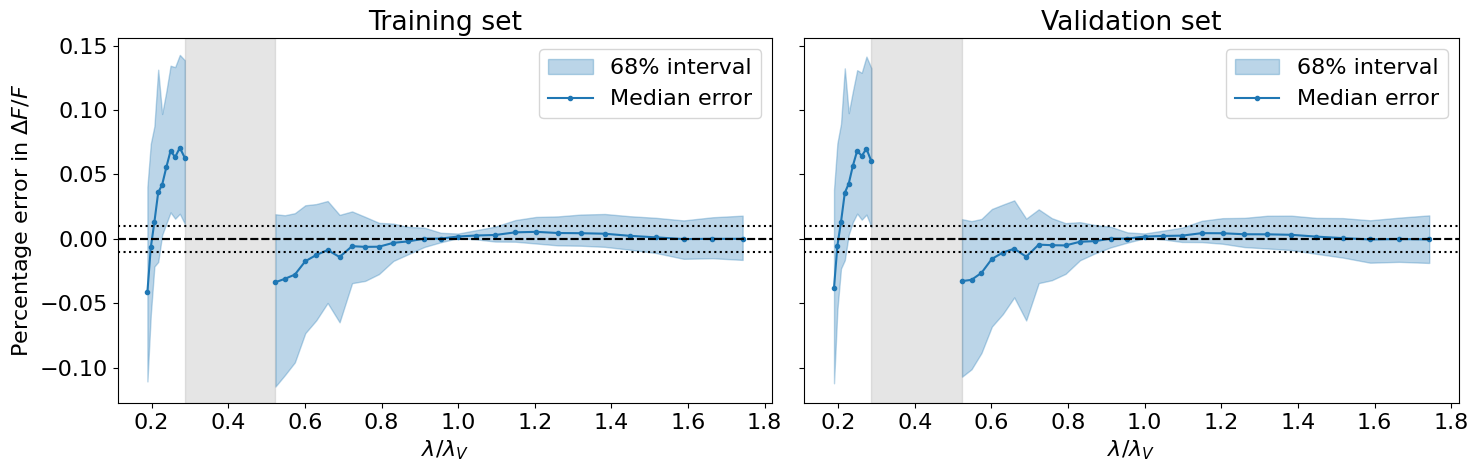

In [51]:
def compute_initial_C(IOB):
    c = [0.908373, 0.748169, 0.944124, 59.20784, 5.327414, 0.010842]
    B0 = c[0]*np.log(IOB[0]*c[3] + c[4])
    C0 = B0 * np.log(10)
    return C0

def compute_Av(x, b, C0):
    A_over_Av = b[0] * np.exp(C0*(np.tanh(b[1]) - np.tanh(b[1]*x)))
    return A_over_Av

def loss_fun_b(b, x, A_true, A_v, C0):
    A_pred = compute_Av(x, b, C0)
    # loss = np.sqrt(np.mean((np.log(ypred) - np.log(ytrue))**2))
    dF_F_train = 10. ** (0.4 * A_v * (A_true - A_pred)) - 1.0
    loss = np.sqrt(np.mean(dF_F_train**2))
    return loss

b_init = [10 ** (-0.0108420000000000), 0.944124]

args = OperonArgs(ini_file)

# Load training and validation data
dirname = pjoin(args.out_data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')
df_train = pd.read_csv(fname_train, sep=r'\s+')
df_val = pd.read_csv(fname_val, sep=r'\s+')

# Get the normalisation of the curves
df_all_train = pd.read_csv(args.selection.train_file)
df_all_val = pd.read_csv(args.selection.val_file)
log_Av_col = f'logA_{int(args.lambda_V*1e4)}A'
A_v_col = f'A_{int(args.lambda_V*1e4)}A'
if log_Av_col in df_all_train.columns:
    lv_key = log_Av_col
elif A_v_col in df_all_train.columns:
    lv_key = A_v_col
else:
    raise ValueError("Column with lambda_V not found in input file")

# Get A_v for training and validation sets so we can calculate dF/F after fitting
train_id = df_train['galaxy_id'].values
train_los = df_train['los'].values
val_id = df_val['galaxy_id'].values
val_los = df_val['los'].values
m = df_all_train.set_index(['galaxy_id', 'los'])
train_Av = m.loc[list(zip(train_id, train_los)), lv_key].values
m = df_all_val.set_index(['galaxy_id', 'los'])
val_Av = m.loc[list(zip(val_id, val_los)), lv_key].values

print(df_train.shape, train_Av.shape)

# Extract IOB values and variables we care about
IOB_cols = sorted([col for col in df_train.columns if re.match(r'IOB\d+', col)])
IOB_train = df_train[IOB_cols].values
IOB_val = df_val[IOB_cols].values
x_train = df_train['lam'].values
x_val = df_val['lam'].values

# Get C0 for training and validation sets
C0_train = compute_initial_C(IOB_train.T)
C0_val = compute_initial_C(IOB_val.T)

A_train = df_train['A'].values
A_val = df_val['A'].values

print(f'\nInitial b parameters: {b_init}')
print(f'Training loss with initial b: {loss_fun_b(b_init, x_train, A_train, train_Av, C0_train)}')
print(f'Validation loss with initial b: {loss_fun_b(b_init, x_val, A_val, val_Av, C0_val)}')

# Optimise b parameters
res = scipy.optimize.minimize(loss_fun_b, b_init, args=(x_train, A_train, train_Av, C0_train), method='Nelder-Mead')
print(f'\n{res.success}, {res.message}\n')
b_opt = res.x

print(f'Optimised b parameters: {b_opt}')
print(f'Training loss with optimised b: {loss_fun_b(b_opt, x_train, A_train, train_Av, C0_train)}')
print(f'Validation loss with optimised b: {loss_fun_b(b_opt, x_val, A_val, val_Av, C0_val)}')

# Obtain percentiles of errors on training set at fixed x values
# Get median and 68% intervals
x_uniq = np.unique(x_train)
dF_errs_train = np.zeros((len(x_uniq), 3))
dF_errs_val = np.zeros((len(x_uniq), 3))
for i, xval in enumerate(x_uniq):

    indices = np.where(x_train == xval)[0]
    A_true_x = A_train[indices]
    A_pred_x = compute_Av(xval, b_opt, C0_train[indices])
    dF_F = 10. ** (0.4 * train_Av[indices] * (A_pred_x - A_true_x)) - 1.0
    dF_errs_train[i,0] = np.percentile(dF_F, 16.)
    dF_errs_train[i,1] = np.percentile(dF_F, 50.)
    dF_errs_train[i,2] = np.percentile(dF_F, 84.)

    indices = np.where(x_val == xval)[0]
    A_true_x = A_val[indices]
    A_pred_x = compute_Av(xval, b_opt, C0_val[indices])
    dF_F = 10. ** (0.4 * val_Av[indices] * (A_pred_x - A_true_x)) - 1.0
    dF_errs_val[i,0] = np.percentile(dF_F, 16.)
    dF_errs_val[i,1] = np.percentile(dF_F, 50.)
    dF_errs_val[i,2] = np.percentile(dF_F, 84.)

mlow = x_uniq <= args.lam_bump_min / args.lambda_V
mhigh = x_uniq >= args.lam_bump_max / args.lambda_V

fig, axs = plt.subplots(1, 2, figsize=(15,5), sharey=True)
axs[0].fill_between(x_uniq[mlow], dF_errs_train[mlow,0], dF_errs_train[mlow,2], color='C0', alpha=0.3, label='68% interval')
axs[0].fill_between(x_uniq[mhigh], dF_errs_train[mhigh,0], dF_errs_train[mhigh,2], color='C0', alpha=0.3)
axs[0].plot(x_uniq[mlow], dF_errs_train[mlow,1], marker='.', label='Median error', color='C0')
axs[0].plot(x_uniq[mhigh], dF_errs_train[mhigh,1], marker='.', color='C0')
axs[0].axhline(0., color='k', ls='--')
axs[0].set_xlabel(r'$\lambda / \lambda_V$')
axs[0].set_ylabel(r'Percentage error in $\Delta F / F$')
axs[0].legend()
axs[1].fill_between(x_uniq[mlow], dF_errs_val[mlow,0], dF_errs_val[mlow,2], color='C0', alpha=0.3, label='68% interval')
axs[1].fill_between(x_uniq[mhigh], dF_errs_val[mhigh,0], dF_errs_val[mhigh,2], color='C0', alpha=0.3)
axs[1].plot(x_uniq[mlow], dF_errs_val[mlow,1], marker='.', label='Median error', color='C0')
axs[1].plot(x_uniq[mhigh], dF_errs_val[mhigh,1], marker='.', color='C0')
axs[1].axhline(0., color='k', ls='--')
axs[1].set_xlabel(r'$\lambda / \lambda_V$')
axs[1].legend()
axs[0].set_title('Training set')
axs[1].set_title('Validation set')
for ax in axs:
    ax.axhline(0., color='k', ls='--')
    ax.axhline(0.01, color='k', ls=':')
    ax.axhline(-0.01, color='k', ls=':')
    xlow = max(x_uniq[mlow])
    xhigh = min(x_uniq[mhigh])
    ylim = ax.get_ylim()
    ax.fill_betweenx(ax.get_ylim(), xlow, xhigh, color='grey', alpha=0.2)
    ax.set_ylim(ylim)
fig.tight_layout()

After fixing the $b$ parameters, we re-optimised the C0. Compare the losses for each gal and the values of C0

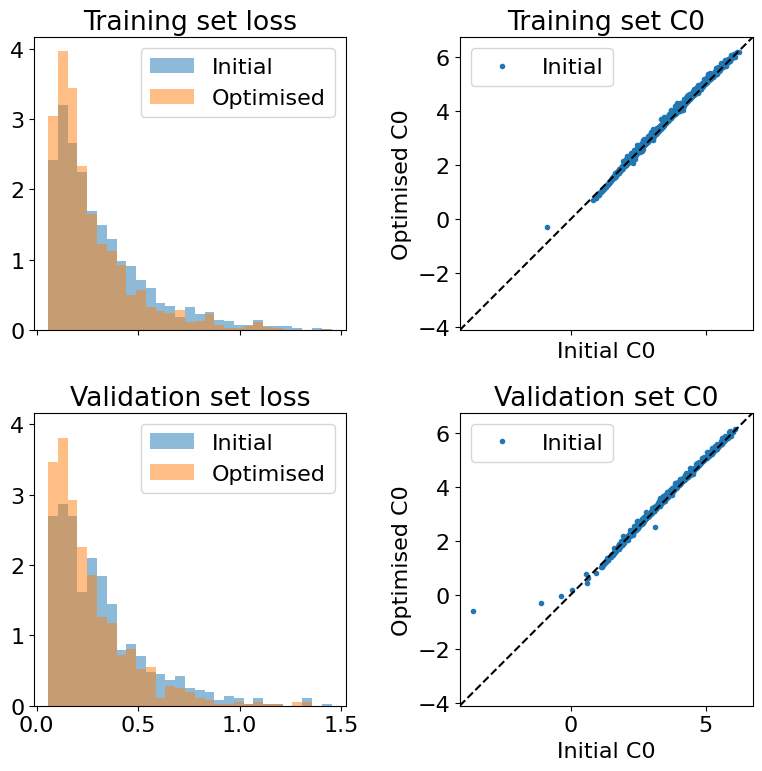

In [71]:
fname_train = '/mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/outer_fit_results_train.csv'
df_results_train = pd.read_csv(fname_train)
fname_val = '/mnt/users/deaglan/symbolic_regression/iob-attenuation/symbolic_regression/data/outer_fit_results_val.csv'
df_results_val = pd.read_csv(fname_val)

fig, axs = plt.subplots(2, 2, figsize=(8,8), sharey='col', sharex='col')

bins = np.linspace(np.percentile(df_results_train['loss_init'], 0.5), np.percentile(df_results_train['loss_init'], 99.5), 30)
axs[0,0].hist(df_results_train['loss_init'], bins=bins, density=True, alpha=0.5, label='Initial')
axs[0,0].hist(df_results_train['loss_opt'], bins=bins, density=True, alpha=0.5, label='Optimised')
axs[1,0].hist(df_results_val['loss_init'], bins=bins, density=True, alpha=0.5, label='Initial')
axs[1,0].hist(df_results_val['loss_opt'], bins=bins, density=True, alpha=0.5, label='Optimised')

axs[0,1].plot(df_results_train['C0_init'], df_results_train['C0_opt'], '.', label='Initial')
axs[1,1].plot(df_results_val['C0_init'], df_results_val['C0_opt'], '.', label='Initial')
for ax in axs[:,1]:
    ax.set_xlabel('Initial C0')
    ax.set_ylabel('Optimised C0')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xlim = (min(xlim[0], ylim[0]), max(xlim[1], ylim[1]))
    ylim = xlim
    ax.plot(xlim, ylim, 'k--')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal', 'box')
for ax in axs.flatten():
    ax.legend()
axs[0,0].set_title('Training set loss')
axs[1,0].set_title('Validation set loss')
axs[0,1].set_title('Training set C0')
axs[1,1].set_title('Validation set C0')
fig.tight_layout()

Now see how this looks in terms of the attenuation curve

(54501,) (27232,)


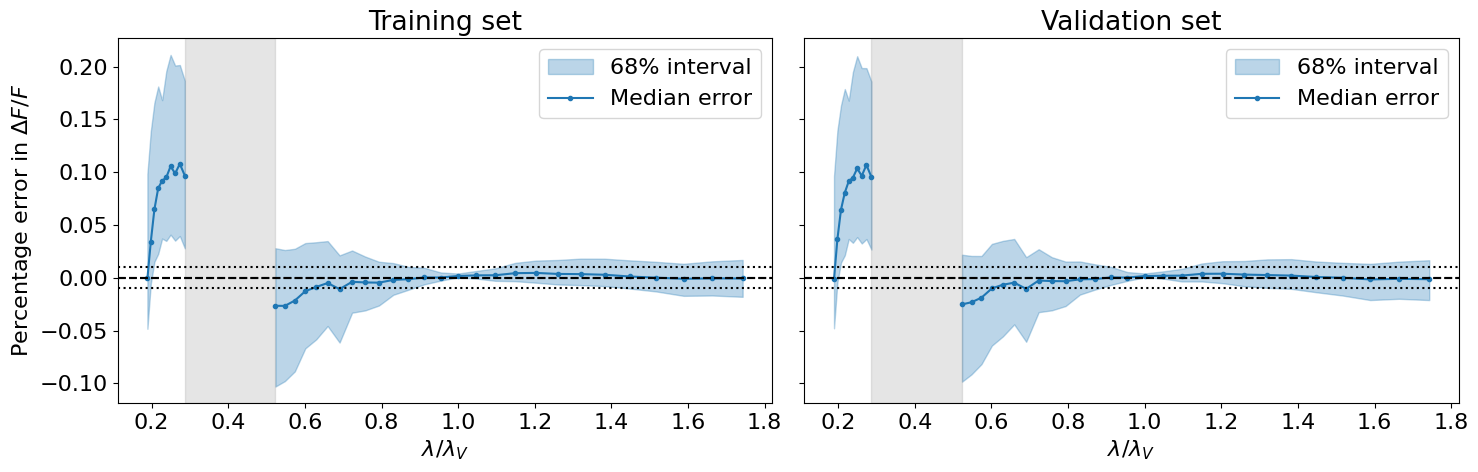

In [80]:
C0_train = df_results_train['C0_opt'].values
C0_val = df_results_val['C0_opt'].values

# Repeat this value so that this has the same shape as our training data
C0_train_full = np.repeat(C0_train, len(x_uniq))
C0_val_full = np.repeat(C0_val, len(x_uniq))
print(C0_train_full.shape, C0_val_full.shape)

# Obtain percentiles of errors on training set at fixed x values
# Get median and 68% intervals
x_uniq = np.unique(x_train)
dF_errs_train = np.zeros((len(x_uniq), 3))
dF_errs_val = np.zeros((len(x_uniq), 3))
for i, xval in enumerate(x_uniq):

    indices = np.where(x_train == xval)[0]
    A_true_x = A_train[indices]
    A_pred_x = compute_Av(xval, b_opt, C0_train_full[indices])
    dF_F = 10. ** (0.4 * train_Av[indices] * (A_pred_x - A_true_x)) - 1.0
    dF_errs_train[i,0] = np.percentile(dF_F, 16.)
    dF_errs_train[i,1] = np.percentile(dF_F, 50.)
    dF_errs_train[i,2] = np.percentile(dF_F, 84.)

    indices = np.where(x_val == xval)[0]
    A_true_x = A_val[indices]
    A_pred_x = compute_Av(xval, b_opt, C0_val_full[indices])
    dF_F = 10. ** (0.4 * val_Av[indices] * (A_pred_x - A_true_x)) - 1.0
    dF_errs_val[i,0] = np.percentile(dF_F, 16.)
    dF_errs_val[i,1] = np.percentile(dF_F, 50.)
    dF_errs_val[i,2] = np.percentile(dF_F, 84.)
    
mlow = x_uniq <= args.lam_bump_min / args.lambda_V
mhigh = x_uniq >= args.lam_bump_max / args.lambda_V

fig, axs = plt.subplots(1, 2, figsize=(15,5), sharey=True)
axs[0].fill_between(x_uniq[mlow], dF_errs_train[mlow,0], dF_errs_train[mlow,2], color='C0', alpha=0.3, label='68% interval')
axs[0].fill_between(x_uniq[mhigh], dF_errs_train[mhigh,0], dF_errs_train[mhigh,2], color='C0', alpha=0.3)
axs[0].plot(x_uniq[mlow], dF_errs_train[mlow,1], marker='.', label='Median error', color='C0')
axs[0].plot(x_uniq[mhigh], dF_errs_train[mhigh,1], marker='.', color='C0')
axs[0].axhline(0., color='k', ls='--')
axs[0].set_xlabel(r'$\lambda / \lambda_V$')
axs[0].set_ylabel(r'Percentage error in $\Delta F / F$')
axs[0].legend()
axs[1].fill_between(x_uniq[mlow], dF_errs_val[mlow,0], dF_errs_val[mlow,2], color='C0', alpha=0.3, label='68% interval')
axs[1].fill_between(x_uniq[mhigh], dF_errs_val[mhigh,0], dF_errs_val[mhigh,2], color='C0', alpha=0.3)
axs[1].plot(x_uniq[mlow], dF_errs_val[mlow,1], marker='.', label='Median error', color='C0')
axs[1].plot(x_uniq[mhigh], dF_errs_val[mhigh,1], marker='.', color='C0')
axs[1].axhline(0., color='k', ls='--')
axs[1].set_xlabel(r'$\lambda / \lambda_V$')
axs[1].legend()
axs[0].set_title('Training set')
axs[1].set_title('Validation set')
for ax in axs:
    ax.axhline(0., color='k', ls='--')
    ax.axhline(0.01, color='k', ls=':')
    ax.axhline(-0.01, color='k', ls=':')
    xlow = max(x_uniq[mlow])
    xhigh = min(x_uniq[mhigh])
    ylim = ax.get_ylim()
    ax.fill_betweenx(ax.get_ylim(), xlow, xhigh, color='grey', alpha=0.2)
    ax.set_ylim(ylim)
fig.tight_layout()

# Check Distribution of Training and Validation Parameters


Reading from configuration file: conf/iob_0.ini
(46000, 7) (23000, 7)


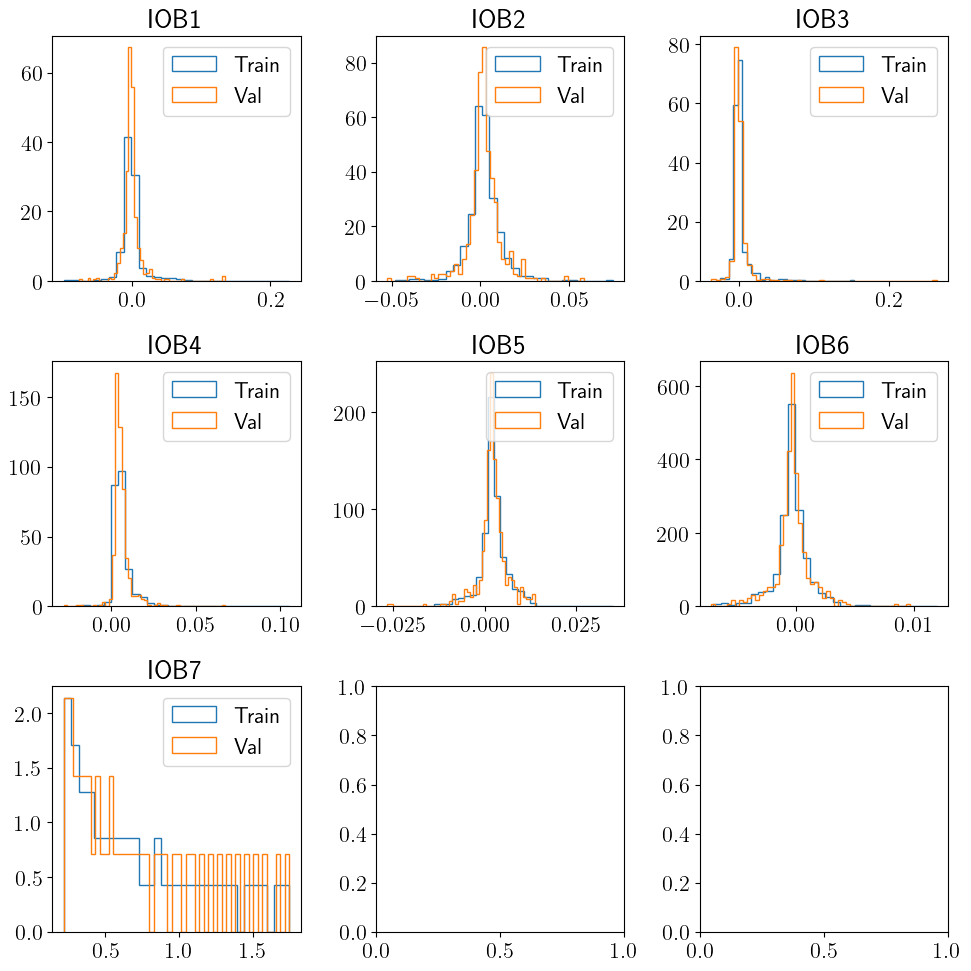

In [114]:
ini_file = 'conf/iob_0.ini'
args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,2:-1]
y = data[:,-1]

with open(fname_val, 'r') as f:
    val_names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_val, skiprows=1)
Xval = data[:,2:-1]

print(X.shape, Xval.shape)

fig, axs = plt.subplots(3, 3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()[:X.shape[1]]):
    ax.hist(X[:,i], bins=30, density=True, histtype='step', label='Train')
    ax.hist(Xval[:,i], bins=50, density=True, histtype='step', label='Val')
    ax.legend()
    ax.set_title(f'IOB{i+1}')
fig.tight_layout()

# Look at distribution of IOB parameter combinations


Reading from configuration file: conf/iob_6.ini

Reading from configuration file: conf/selection_0.ini
-5369.777802441621 138992.38562712393 533.9560958773085 5.14299100909797


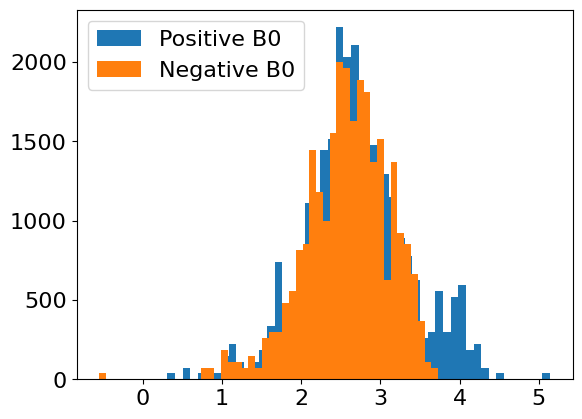

In [18]:
ini_file = 'conf/iob_6.ini';
args = OperonArgs(ini_file)
dirname = pjoin(args.out_data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
data = pd.read_csv(fname_train, sep=r'\s+')

c = [0.999999, 5.160664, 14.21899, 96.767336287521, 346.455505, 418.237518, 308.280884, 64.732704, 69744.210938, 20.115023, 0.989066010925, 0.999999, 2.638054, 7.050597, 91.976021, 4.946947, 0.441919, 0.045192, 1391.598999, 182.675049, 3.984417, 7.549686, 0.985602, 6.911434, 2.567828]
IOB1 = data['IOB1'].values
IOB2 = data['IOB2'].values
IOB3 = data['IOB3'].values
B0 = -c[0]*(-IOB2**2*c[3]*(-IOB1*c[4] - IOB2*c[5] - IOB3*c[6] + c[7])**2 - IOB3*c[8])

print(B0.min(), B0.max(), B0.mean(), np.log10(np.abs(B0)).max())

m = B0 > 0
plt.hist(np.log10(B0[m]), bins=50, label='Positive B0')
plt.hist(np.log10(-B0[~m]), bins=50, label='Negative B0')
plt.legend()

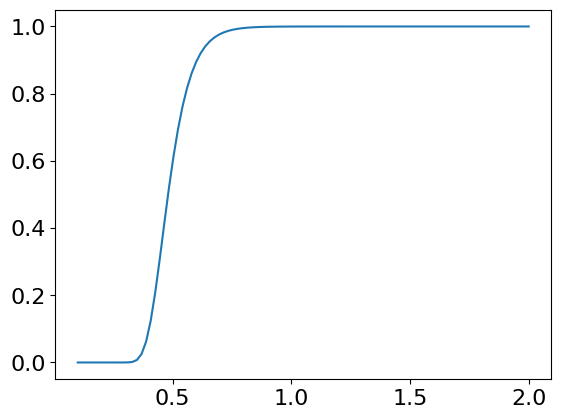

In [31]:
x = np.linspace(0.1, 2, 100)
a8 = -5908.80419900000
a10 = -17.3103690000000
y = np.exp(a8 * x * np.exp(a10 * x))
plt.plot(x, y)